In [25]:
import tensorflow as tf
import os
import cv2
from matplotlib import pyplot as plt
import numpy as np


In [26]:
!pip list

Package                      Version
---------------------------- --------------------
absl-py                      1.1.0
asttokens                    2.0.5
astunparse                   1.6.3
backcall                     0.2.0
cachetools                   5.2.0
certifi                      2022.6.15
charset-normalizer           2.1.0
colorama                     0.4.5
cycler                       0.11.0
debugpy                      1.5.1
decorator                    5.1.1
entrypoints                  0.4
executing                    0.8.3
flatbuffers                  2.0
fonttools                    4.25.0
gast                         0.4.0
google-auth                  2.9.1
google-auth-oauthlib         0.4.6
google-pasta                 0.2.0
grpcio                       1.47.0
h5py                         3.7.0
idna                         3.3
importlib-metadata           4.12.0
ipykernel                    6.9.1
ipython                      8.4.0
jedi                         0.18.1


In [27]:
print("Num GPUs Available: ", len(tf.config.experimental.list_physical_devices('GPU')))

Num GPUs Available:  1


In [28]:
gpus = tf.config.list_physical_devices("GPU")
for gpu in gpus:
    tf.config.experimental.set_memory_growth(gpu, False)

print("Number GPUs Available: ", len(tf.config.list_physical_devices("GPU")))


Number GPUs Available:  1


In [29]:
# check how it works/convert image's color BGR to RGB 
"""images_directory = 'Tree_images'
images_ext = ['jpg', 'jpeg', 'png', 'bmp']
img = cv2.imread(os.path.join('Tree_images','MAPLE', "190_ERR_100_Nexus 5_20170608_095430_2.jpg"))
img.shape
type(img)
plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))""" 

'images_directory = \'Tree_images\'\nimages_ext = [\'jpg\', \'jpeg\', \'png\', \'bmp\']\nimg = cv2.imread(os.path.join(\'Tree_images\',\'MAPLE\', "190_ERR_100_Nexus 5_20170608_095430_2.jpg"))\nimg.shape\ntype(img)\nplt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))'

In [30]:
#checking images extension- delete unmatched
#if you are sure about your input images (correct extension) skip this step
'''
for images_tree_species in os.listdir(images_directory):
    print (len(os.listdir(os.path.join(images_directory, images_tree_species))))
    #for images in os.listdir(os.path.join(images_directory, images_tree_species)):
    for images in os.listdir(os.path.join(images_directory, images_tree_species)):
        image_path = os.path.join(images_directory, images_tree_species, images)
        try:
            img = cv2.imread(image_path)
            ext_test = imghdr.what(image_path)
            if ext_test not in images_ext:
                print('Image not in extesion list {}'.format(image_path))
                os.remove(image_path)
        except Exception as error:
            print('Issue with image {}'.format(image_path))
            '''


"\nfor images_tree_species in os.listdir(images_directory):\n    print (len(os.listdir(os.path.join(images_directory, images_tree_species))))\n    #for images in os.listdir(os.path.join(images_directory, images_tree_species)):\n    for images in os.listdir(os.path.join(images_directory, images_tree_species)):\n        image_path = os.path.join(images_directory, images_tree_species, images)\n        try:\n            img = cv2.imread(image_path)\n            ext_test = imghdr.what(image_path)\n            if ext_test not in images_ext:\n                print('Image not in extesion list {}'.format(image_path))\n                os.remove(image_path)\n        except Exception as error:\n            print('Issue with image {}'.format(image_path))\n            "

In [31]:
input_data = tf.keras.utils.image_dataset_from_directory('Tree_images')
input_data_iterator = input_data.as_numpy_iterator()
input_data_iterator

Found 3840 files belonging to 3 classes.


In [32]:
batch = input_data_iterator.next()
batch[1]

array([1, 0, 2, 2, 1, 1, 1, 1, 1, 0, 0, 2, 1, 2, 2, 1, 2, 2, 0, 1, 1, 1,
       1, 2, 1, 2, 1, 2, 1, 0, 2, 2])

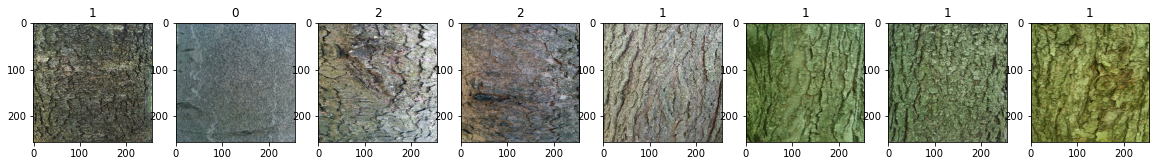

In [33]:
figure, ax = plt.subplots(ncols=8, figsize=(20,20))
for index, images in enumerate(batch[0][:8]):
    ax[index].imshow(images.astype('uint8'))
    ax[index].title.set_text(batch[1][index])

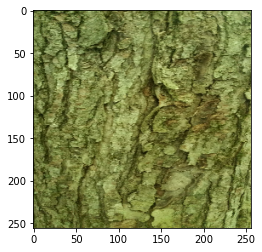

In [34]:
plt.imshow(images.astype('uint8'))

# Preprocessing 
- split data
- rescale images (batch normalization?) - significantly reducing the need for computing power (range 0-255 to 0-1)


In [35]:
batch[0].shape

(32, 256, 256, 3)

In [36]:
input_data = input_data.map(lambda x,y: (x/255,y))

In [37]:
input_data.as_numpy_iterator().next()[0].max()

1.0

In [38]:
input_data.as_numpy_iterator().next()[0].shape

(32, 256, 256, 3)

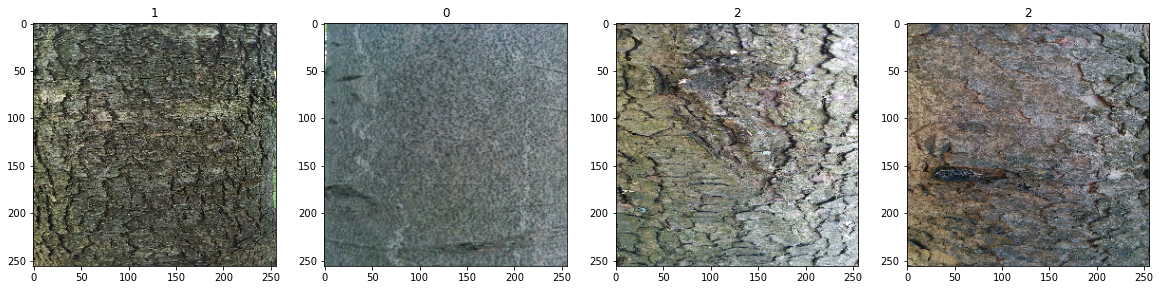

In [39]:
figure, ax = plt.subplots(ncols=4, figsize=(20,20))
for index, images in enumerate(batch[0][:4]):
    ax[index].imshow(images.astype('uint8'))
    ax[index].title.set_text(batch[1][index])

In [40]:
#split data
len(input_data)

120

In [41]:
train_size = int(len(input_data)*.7)
val_size = int(len(input_data)*.2)
test_size = int(len(input_data)*.1)

In [42]:
train_size+val_size+test_size

120

In [43]:
train = input_data.take(train_size)
val = input_data.skip(train_size).take(val_size)
test = input_data.skip(train_size+val_size).take(test_size)

# CNN model

In [44]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Dense, Flatten, Dropout

In [46]:
model = tf.keras.models.Sequential([
    tf.keras.layers.Conv2D(filters=96, kernel_size=(11,11), strides=(4,4), activation='relu', input_shape=(256,256,3)),
    tf.keras.layers.Lambda(tf.nn.local_response_normalization),
    tf.keras.layers.MaxPool2D(pool_size=(3,3), strides=(2,2)),
    tf.keras.layers.Conv2D(filters=256, kernel_size=(5,5), strides=(1,1), activation='relu', padding="same"),
    tf.keras.layers.Lambda(tf.nn.local_response_normalization),
    tf.keras.layers.MaxPool2D(pool_size=(3,3), strides=(2,2)),
    tf.keras.layers.Conv2D(filters=384, kernel_size=(3,3), strides=(1,1), activation='relu', padding="same"),
    tf.keras.layers.Lambda(tf.nn.local_response_normalization),
    tf.keras.layers.Conv2D(filters=384, kernel_size=(3,3), strides=(1,1), activation='relu', padding="same"),
    tf.keras.layers.Lambda(tf.nn.local_response_normalization),
    tf.keras.layers.Conv2D(filters=256, kernel_size=(3,3), strides=(1,1), activation='relu', padding="same"),
    tf.keras.layers.Lambda(tf.nn.local_response_normalization),
    tf.keras.layers.MaxPool2D(pool_size=(3,3), strides=(2,2)),
    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(4096, activation='relu'),
    tf.keras.layers.Dropout(0.5),
    tf.keras.layers.Dense(4096, activation='relu'),
    tf.keras.layers.Dropout(0.5),
    tf.keras.layers.Dense(3, activation='softmax')
  ])

In [52]:
model.compile('adam', loss='mse', metrics=['accuracy'])

In [53]:
model.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv2d_5 (Conv2D)           (None, 62, 62, 96)        34944     
                                                                 
 lambda_5 (Lambda)           (None, 62, 62, 96)        0         
                                                                 
 max_pooling2d_3 (MaxPooling  (None, 30, 30, 96)       0         
 2D)                                                             
                                                                 
 conv2d_6 (Conv2D)           (None, 30, 30, 256)       614656    
                                                                 
 lambda_6 (Lambda)           (None, 30, 30, 256)       0         
                                                                 
 max_pooling2d_4 (MaxPooling  (None, 14, 14, 256)      0         
 2D)                                                    

In [54]:
logdir = 'new_logs'

In [55]:
tensorboard_callback = tf.keras.callbacks.TensorBoard(log_dir=logdir)

In [56]:
hist = model.fit(train, epochs=20, validation_data=val, callbacks=[tensorboard_callback])

Epoch 1/20
84/84 [==============================] - 45s 467ms/step - loss: 1.1666 - accuracy: 0.3482 - val_loss: 1.2161 - val_accuracy: 0.2539
Epoch 2/20
84/84 [==============================] - 42s 480ms/step - loss: 1.1667 - accuracy: 0.3188 - val_loss: 1.1866 - val_accuracy: 0.2253
Epoch 3/20
84/84 [==============================] - 44s 499ms/step - loss: 1.1639 - accuracy: 0.3583 - val_loss: 1.2526 - val_accuracy: 0.2201
Epoch 4/20
84/84 [==============================] - 45s 517ms/step - loss: 1.1677 - accuracy: 0.3471 - val_loss: 1.2530 - val_accuracy: 0.2513
Epoch 5/20
84/84 [==============================] - 43s 497ms/step - loss: 1.1713 - accuracy: 0.3356 - val_loss: 1.1988 - val_accuracy: 0.4089
Epoch 6/20
84/84 [==============================] - 43s 496ms/step - loss: 1.1729 - accuracy: 0.3475 - val_loss: 1.1832 - val_accuracy: 0.4141
Epoch 7/20
84/84 [==============================] - 44s 507ms/step - loss: 1.1574 - accuracy: 0.3508 - val_loss: 1.1680 - val_accuracy: 0.4206